<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Model-agnostic Explanations**


## **Introduction**

In this lab, we first train a Random Forest model to predict whether an employee is looking for a job change. Random Forest models can provide built-in feature importance, but they still contain many trees and many decision paths, so it can be hard to understand their full prediction behavior. For this lab, we treat the Random Forest as a **black-box model** and explain it with methods that can also be used for other model types.

The goal of this lab is to use **model-agnostic explanation methods**. Model-agnostic means the explanation method can be used with many different types of machine learning models, not just one model type.

This lab introduces **four main explanation methods**:

*   **Permutation feature importance** explains which features are important overall. It checks how much model performance drops when the values of one feature are randomly shuffled. If performance drops a lot, that feature is important.
*   **Partial Dependence Plot (PDP)** shows how the model prediction changes as one feature changes, while averaging over the other features.
*   **Global surrogate models** explain the black-box model by training a simpler model to copy its predictions. The simpler model, such as a Decision Tree or Logistic Regression model, is easier to inspect.
*   **LIME** is a local surrogate method. It explains one prediction at a time by creating small changes around one data example and learning which features influenced that specific prediction.

In short, permutation feature importance and PDP help explain the model's overall behavior. Global surrogate models approximate the whole black-box model with a simpler model. LIME explains one individual prediction.

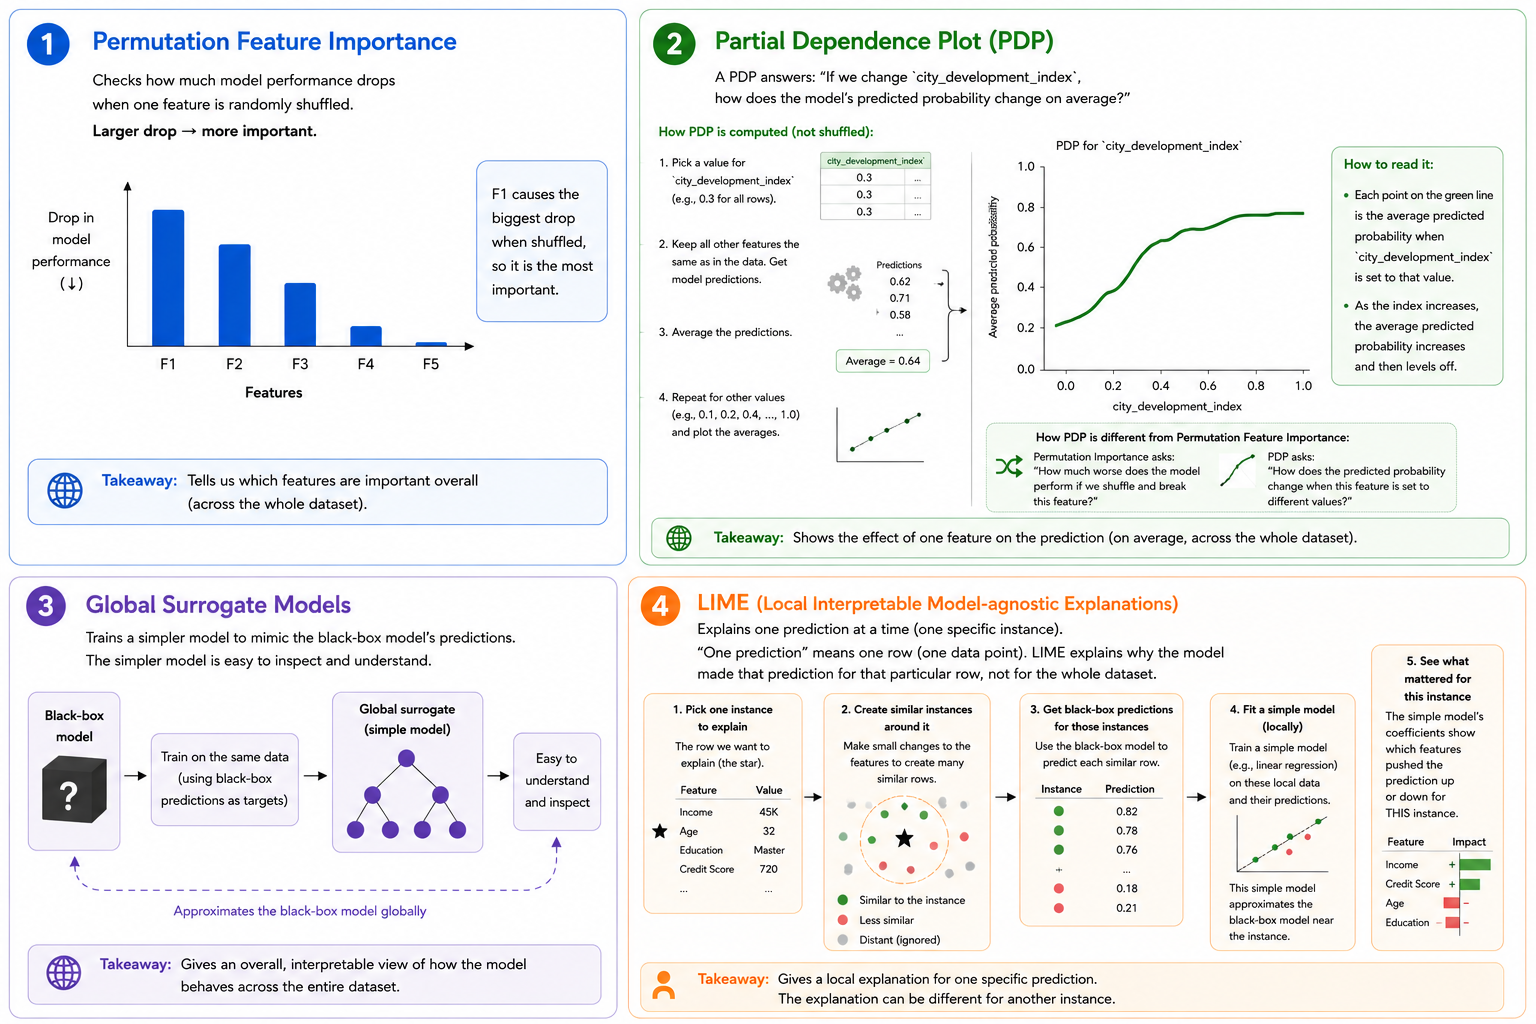

## **Objectives**


* Calculate permutation feature importance
* Use Partial Dependence Plots to show relationships between features and model predictions
* Build global surrogate models
* Build local surrogate models using `LIME`


----


## **Workflow**
### **Setup**

Let's import the Python packages required for this lab:


Now, import the required Python packages.


In [ ]:
## Import packages here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lime.lime_tabular

from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import (
    DecisionTreeClassifier,
    export_text,
    export_graphviz,
    plot_tree,
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

Next, load the dataset used in this lab.


In [ ]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML201EN-SkillsNetwork/labs/module_4/datasets/hr_new_job_processed.csv"
job_df = pd.read_csv(url)

In [115]:
job_df.describe()

,city_development_index,training_hours,company_size,experience,education_level,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,target
count,11504.000000,11504.000000,11504.000000,11504.000000,11504.000000,11504.000000,11504.000000,11504.000000,11504.000000,11504.000000,11504.000000,11504.000000
mean,0.806056,64.380421,2.748997,9.530985,2.131568,0.029180,0.042537,0.023619,0.005557,0.045442,0.853665,0.500000
std,0.128302,59.048600,1.783676,6.733267,0.627610,0.161802,0.197495,0.147348,0.070875,0.200717,0.342167,0.500022
min,0.448000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.682000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.878000,46.000000,2.000000,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.500000
75%,0.920000,88.000000,3.000000,15.000000,2.247823,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,0.949000,336.000000,7.000000,21.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


The dataset contains the following features (predictors):

- `city_development_index`: Development index of the city, ranging from 0 to 1
- `training_hours`: Training hours completed, ranging from 0 to 336
- `company_size`: Size of the current company, ranging from 0 to 7, where 0 means fewer than 10 employees and 7 means more than 10,000 employees
- `education_level`: Education level of the candidate, ranging from 0 to 4, where 0 means Primary School and 4 means PhD
- `experience`: Total experience in years, ranging from 0 to 21
- `company_type`: _Categorical column_ with one-hot encodings. Type of current company: 'Pvt Ltd', 'Funded Startup', 'Early Stage Startup', 'Other', 'Public Sector', or 'NGO'

The prediction outcome is:
- `target`: `0` means not looking for a job change, and `1` means looking for a job change


The predictive task is a binary classification task. We use an employee's profile features to predict whether the employee is looking for a job change.


### **Build a Random Forest classifier as the black-box model**


#### **Train-Test Split**


In [ ]:
X = job_df.loc[:, job_df.columns != "target"]
y = job_df[["target"]]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=12
)

#### **Random Forest Model** 
Now let's train a `Random Forest` model with the following preset arguments. You may also use hyperparameter tuning methods to tune these parameters yourself.
- `random_state = 123` sets the random seed so the results can be reproduced
- `max_depth = 25` means each tree can have a maximum depth of 25
- `max_features = 10` means each split can consider up to 10 features
- `n_estimators = 100` means 100 trees will be built
- `bootstrap = True` means bootstrap samples will be used to build the trees


In [ ]:
# Define a black-box random forest model
black_box_model = RandomForestClassifier(
    random_state=123,
    max_depth=25,
    max_features=10,
    n_estimators=100,
    bootstrap=True,
)
# Train the model
black_box_model.fit(X_train, y_train.values.ravel())

RandomForestClassifier(max_depth=25, max_features=10, random_state=123)

Next, make predictions and evaluate the model using the `AUC` score:


In [ ]:
# Predict the test set
y_blackbox = black_box_model.predict(X_test)

In [120]:
metrics.roc_auc_score(y_test, y_blackbox)

0.8131250708268802

The AUC score is around `0.81`, which indicates that the model performs well on the test dataset.


Now that we have trained a black-box Random Forest model, we can use model-agnostic methods to explain it. 


### **Permutation Feature Importance**


**Permutation feature importance** is a way to measure how much each feature helps a trained model make good predictions.


The idea is simple:

*   First, measure the model's normal performance.
*   Next, choose one feature and randomly shuffle its values.
*   Then, use the model to make predictions again with that shuffled feature.
*   Finally, compare the new performance with the original performance.

If the model performs much worse after one feature is shuffled, that feature is important. If the performance barely changes, the model probably does not rely much on that feature.


In this lab, we use scikit-learn's `permutation_importance` function to calculate the importance of all features.


Call `permutation_importance` with the following key arguments:

- `estimator`: the trained model we want to explain
- `X`: the feature data used to calculate feature importance
- `y`: the target labels used to score the model after shuffling
- `n_repeats`: the number of times to shuffle each feature. More repeats give a more stable estimate.


In [ ]:
# Use permutation_importance to calculate permutation feature importances
feature_importances = permutation_importance(
    estimator=black_box_model,
    X=X_train,
    y=y_train,
    n_repeats=5,
    random_state=123,
    n_jobs=2,
)

Now let's look at the generated importance results:


In [122]:
feature_importances.importances.shape

(11, 5)

In [123]:
feature_importances.importances

array([[0.30468326, 0.30109747, 0.30392263, 0.30174943, 0.30479192],
       [0.15527545, 0.15103771, 0.15092904, 0.15190699, 0.15603608],
       [0.18200587, 0.18309247, 0.18537433, 0.18254917, 0.18993806],
       [0.15353689, 0.15114637, 0.15168967, 0.1472346 , 0.1562534 ],
       [0.1201782 , 0.11789634, 0.11561447, 0.11659242, 0.11517983],
       [0.00076062, 0.00065196, 0.00097794, 0.0005433 , 0.0005433 ],
       [0.00206454, 0.00206454, 0.0021732 , 0.00206454, 0.0016299 ],
       [0.00130392, 0.00141258, 0.00141258, 0.00152124, 0.00119526],
       [0.00076062, 0.0005433 , 0.00065196, 0.0005433 , 0.0005433 ],
       [0.00988808, 0.01043138, 0.00988808, 0.01097468, 0.01097468],
       [0.04813648, 0.04857112, 0.04563729, 0.04704988, 0.04900576]])

The result is an `11 x 5` NumPy array. The `11` means we have 11 features. The `5` means each feature was shuffled 5 times because we used `n_repeats=5`.

Each value is an importance score from one shuffle. Larger values mean model performance dropped more after that feature was shuffled, so the feature is more important to the model.


The array is hard to read directly, so next we sort and visualize the feature importance values:


In [ ]:
def visualize_feature_importance(importance_array):
    # Sort the array based on mean value
    sorted_idx = importance_array.importances_mean.argsort()
    # Visualize the feature importances using boxplot
    fig, ax = plt.subplots()
    fig.set_figwidth(16)
    fig.set_figheight(10)
    fig.tight_layout()
    ax.boxplot(
        importance_array.importances[sorted_idx].T,
        vert=False,
        labels=X_train.columns[sorted_idx],
    )
    ax.set_title("Permutation Importances (train set)")
    plt.show()

/tmp/ipykernel_1062491/1395202523.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(importance_array.importances[sorted_idx].T,


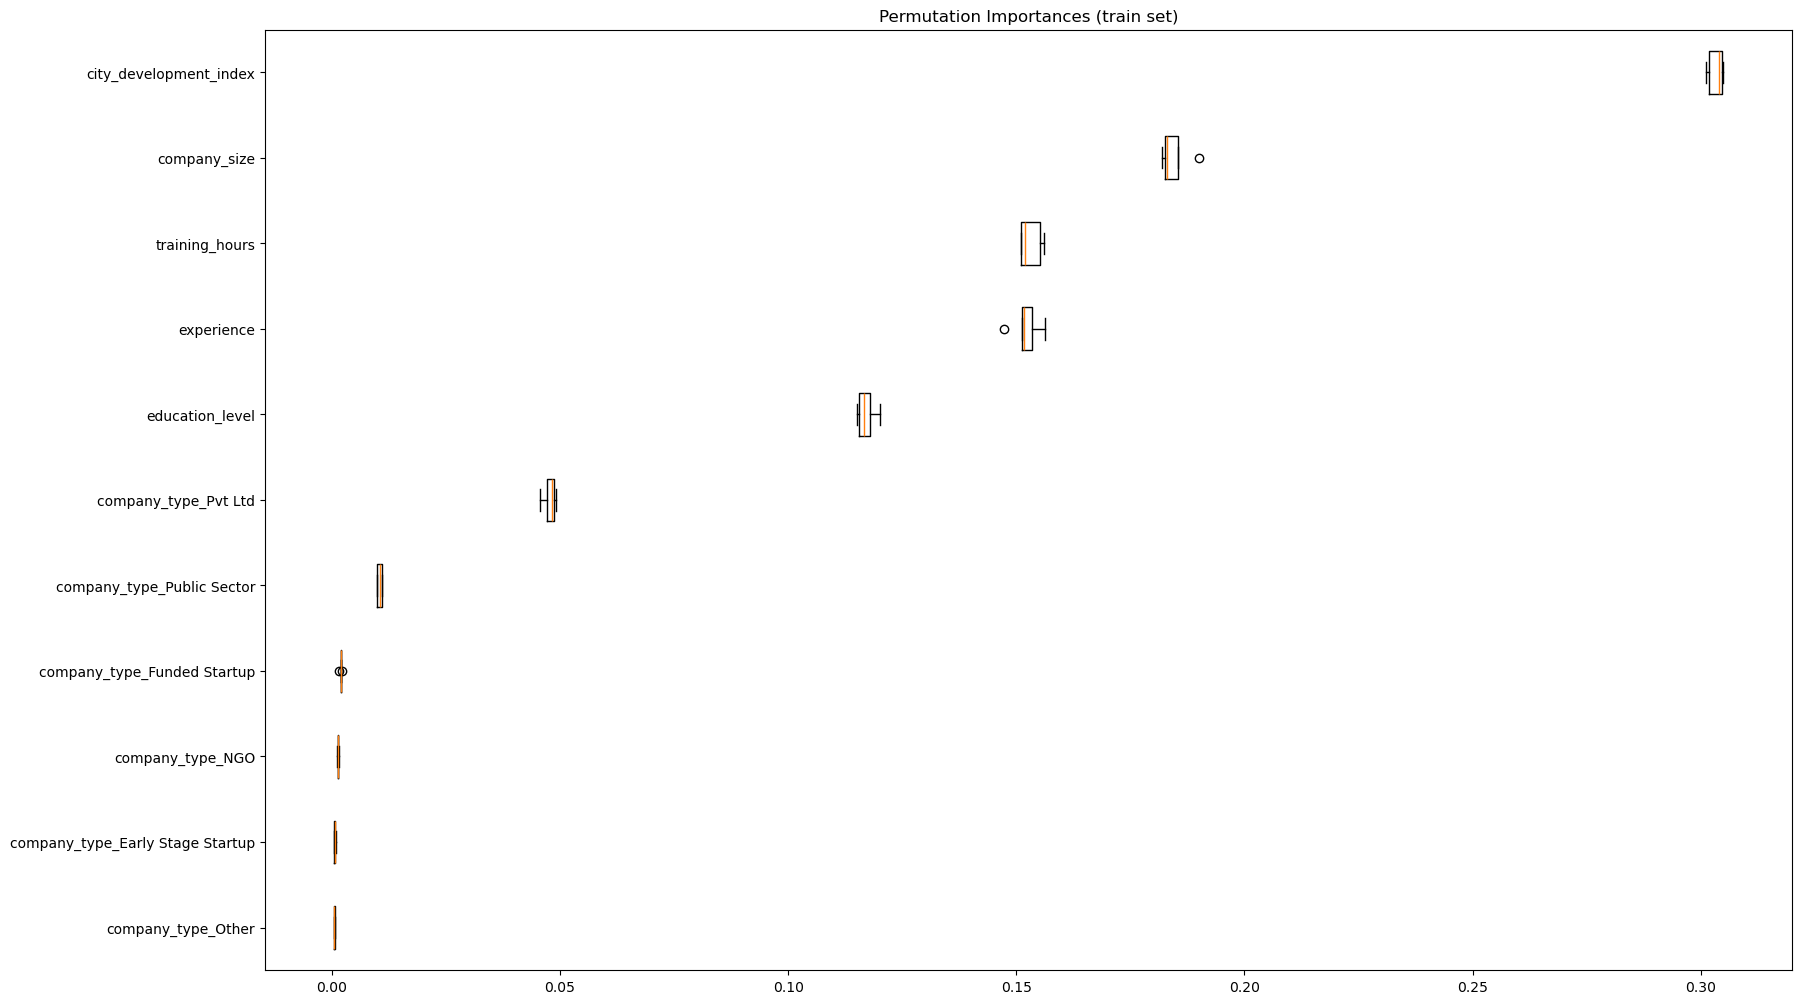

In [125]:
visualize_feature_importance(feature_importances)

The box plot ranks the features by importance. Features near the top have a larger effect on model performance when shuffled. In this example, important features include `city_development_index`, `company_size`, `training_hours`, `experience`, and `education_level`.

This gives us a global explanation of the black-box model. It tells us which features the model depends on most overall, but it does not explain one single prediction.


#### **Exercise**
Use `n_repeats=10` to calculate and visualize the feature importance values.


/tmp/ipykernel_1062491/1395202523.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(importance_array.importances[sorted_idx].T,


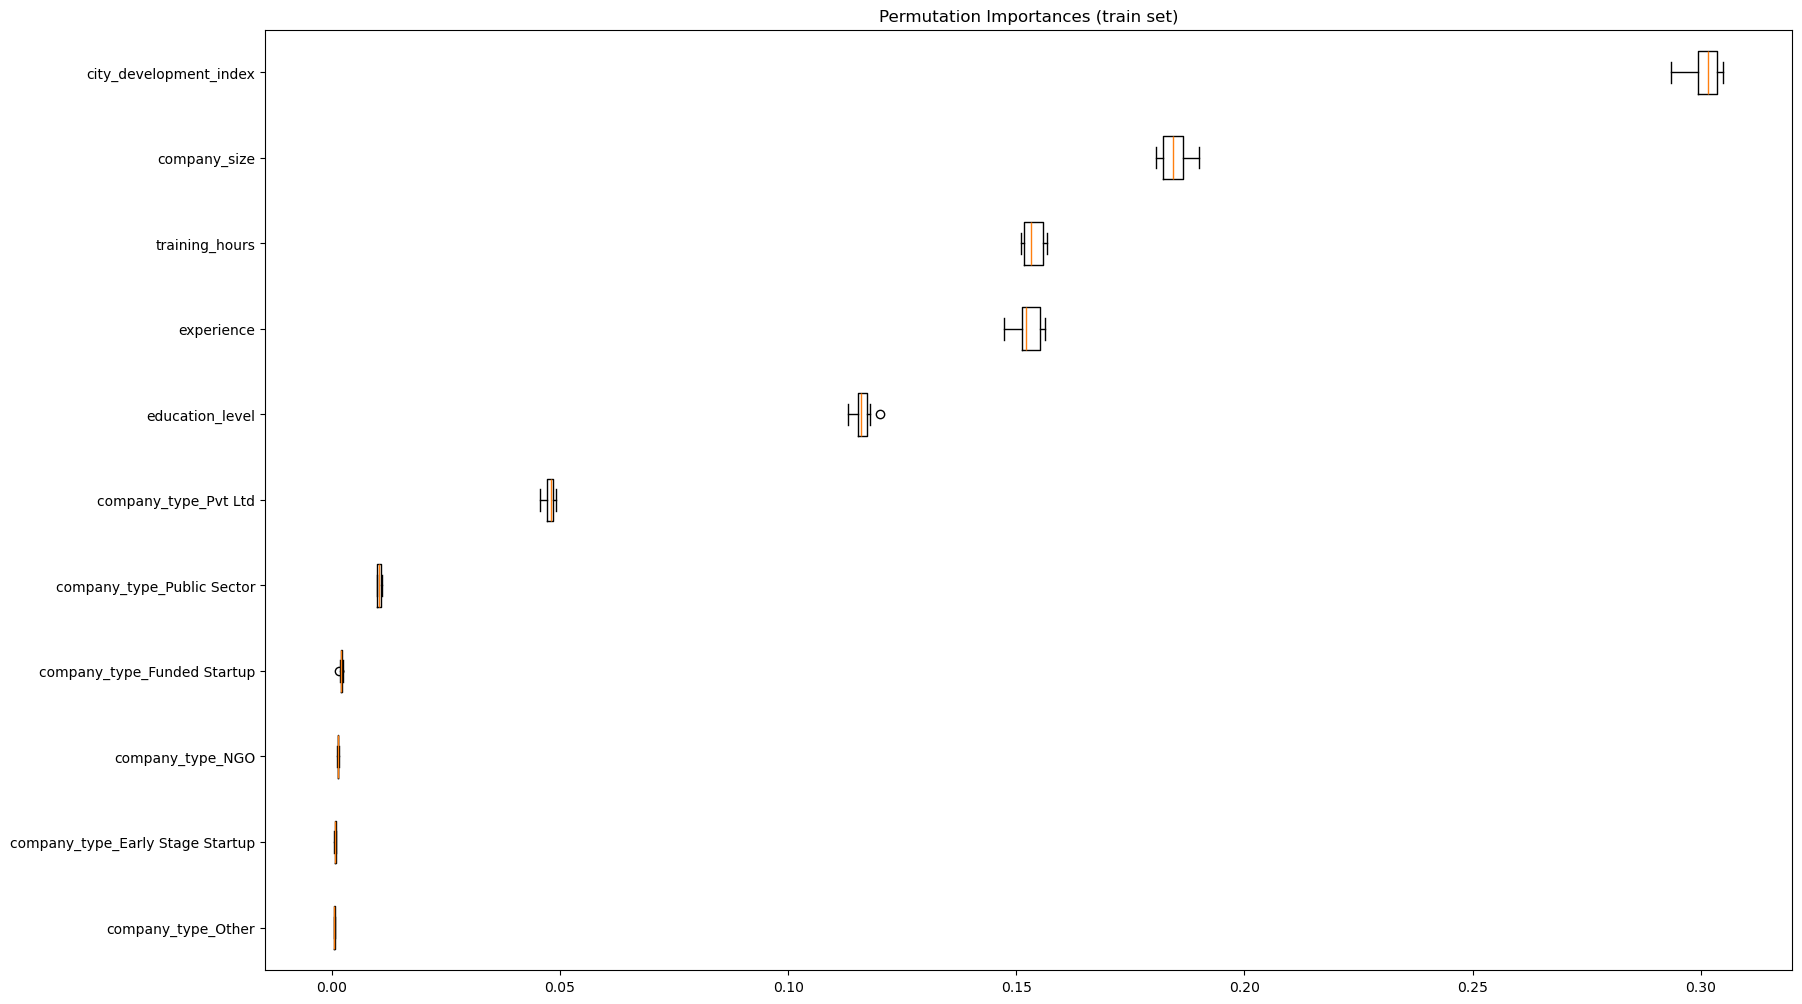

In [ ]:
# Type your answer here
# Update n_repeats=10 and recalculate and visualize feature importance
feature_importances = permutation_importance(
    estimator=black_box_model,
    X=X_train,
    y=y_train,
    n_repeats=10,
    random_state=123,
    n_jobs=2,
)

visualize_feature_importance(feature_importances)

### **Partial Dependence Plot (PDP)**


A **Partial Dependence Plot (PDP)** shows how a model's prediction changes when one feature changes.

A PDP answers a question like this: if we change `city_development_index`, how does the model's predicted probability change on average?

This is different from permutation feature importance. Permutation feature importance asks, "How much worse does the model perform if we shuffle and break this feature?" PDP asks, "How does the predicted probability change when this feature is set to different values?"

To create a PDP, the feature is not shuffled randomly. Instead, the feature is set to one chosen value for all rows, while the other features stay the same. The model makes predictions, and those predictions are averaged. Then the process is repeated for other chosen values of the same feature.


A model may have many features, so we usually do not create a PDP for every feature. Instead, we first use feature importance to find the most important features, then create PDPs for those features.

From the previous section, we saw that important features include `city_development_index`, `company_size`, `experience`, and `education_level`. We can create PDPs for these features using scikit-learn's `PartialDependenceDisplay`.


Let's first create PDPs for `city_development_index` and `experience`:


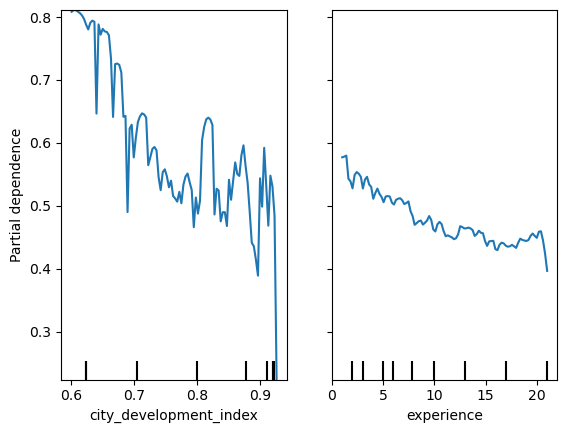

In [ ]:
# Define important features
important_features = ["city_development_index", "experience"]

# Use PartialDependenceDisplay to plot the partial dependence
PartialDependenceDisplay.from_estimator(
    estimator=black_box_model,
    X=X_train,
    features=important_features,
    random_state=123,
)
plt.show()

The plots show the average relationship between each feature and the model's predicted outcome.

In these PDPs, both `city_development_index` and `experience` show a generally negative relationship with the prediction. This means that, on average, as these feature values increase, the model predicts a lower probability that an employee is looking for a job change.

For example, the model tends to predict that employees in more developed cities, or employees with more experience, are less likely to look for a new job.


#### **Exercise** 
Create PDPs for other important features, such as `company_size`, `education_level`, `training_hours`, and others.


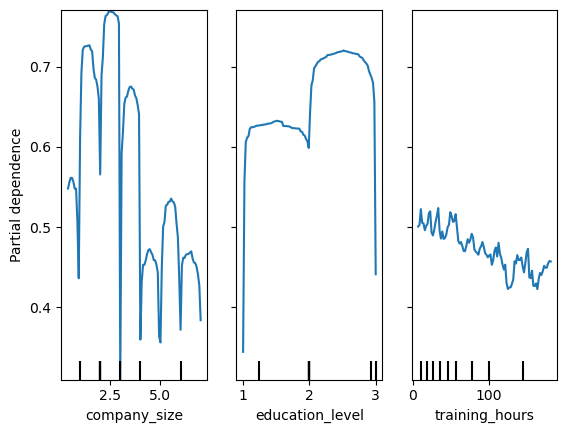

In [ ]:
# Type your solution here
# Create PDPs for other important features
important_features = ["company_size", "education_level", "training_hours"]

PartialDependenceDisplay.from_estimator(
    estimator=black_box_model,
    X=X_train,
    features=important_features,
    random_state=123,
)

#### **Findings**

These PDPs show the model's average prediction pattern for three important features:

- `company_size`: larger companies generally lower the predicted probability of a job change.
- `education_level`: higher education generally raises the predicted probability.
- `training_hours`: the effect is smaller and less consistent.

Overall, `company_size` and `education_level` show clearer effects than `training_hours`. These are global patterns, not explanations for one specific employee.


### **Global Surrogate Model**


So far, we have explained the black-box model by studying how it uses features. Next, we will use a **global surrogate model**.

The idea is simple: train an interpretable model to copy the black-box model's predictions. Then we explain the interpretable model and use that explanation as an approximation of the black-box model.

We are not looking inside the black-box model directly. Instead, we are building a simpler model that behaves like the black-box model, then using the simpler model to understand the black-box model's overall behavior.


In this section, we will use two interpretable models as surrogate models:

*   a Logistic Regression model
*   a Decision Tree model

These models are not trained to predict the original true labels. Instead, they are trained to predict the labels produced by the black-box model.


The general steps are:

- Select a dataset, such as `X_test`.

- Use the black-box model to predict labels for `X_test`. These predictions are stored as `y_blackbox`.

- Train an interpretable surrogate model using `X_test` as the input and `y_blackbox` as the target.

- Use the surrogate model to make predictions. These predictions are called `y_surrogate`.

- Compare `y_surrogate` with `y_blackbox`. A higher match means the surrogate model copied the black-box model more closely.

This match is called **fidelity**. Fidelity measures how well the surrogate model copies the black-box model. It does not measure how well the surrogate model predicts the original true labels.


#### **1. Logistic regression surrogate model**


Before training the Logistic Regression surrogate model, we standardize `X_test`. Standardization puts the features on a similar scale, which makes the coefficients easier to compare.


In [ ]:
# Standardize X_test
standard_scaler = StandardScaler()
X_test_standardized = standard_scaler.fit_transform(X_test)

Next, we train a Logistic Regression model with an `L1` regularizer. The `L1` regularizer can shrink less useful coefficients to zero, which makes the model simpler and easier to interpret.

Remember: the target label here is `y_blackbox`, which comes from the black-box model's predictions.


In [ ]:
lm_surrogate = LogisticRegression(
    max_iter=1000, random_state=123, penalty="l1", solver="liblinear"
)
lm_surrogate.fit(X_test_standardized, y_blackbox)

LogisticRegression(max_iter=1000, penalty='l1', random_state=123,
                   solver='liblinear')

After the surrogate model is trained, we use it to make predictions on `X_test`.


In [131]:
y_surrogate = lm_surrogate.predict(X_test_standardized)

Then we calculate how closely the surrogate model's predictions match the black-box model's predictions.


In [132]:
metrics.accuracy_score(y_blackbox, y_surrogate)

0.7431551499348109

The score is around `0.75`. This means the Logistic Regression surrogate model reproduced about 75% of the black-box model's predictions correctly.

This is useful, but it is not perfect. The explanation from this surrogate model is only an approximation of the black-box model.


Now we can explain the Logistic Regression surrogate model by looking at its feature coefficients.

If this surrogate model has good fidelity, these coefficients give an approximate explanation of how the black-box model makes predictions overall.

The function below extracts the coefficients from `lm_surrogate` and sorts them by value.


In [ ]:
# Extract and sort feature coefficients
def get_feature_coefs(regression_model):
    coef_dict = {}
    # Filter coefficients less than 0.01
    for coef, feat in zip(regression_model.coef_[0, :], X_test.columns):
        if abs(coef) >= 0.01:
            coef_dict[feat] = coef
    # Sort coefficients
    coef_dict = {
        k: v for k, v in sorted(coef_dict.items(), key=lambda item: item[1])
    }
    return coef_dict

In [134]:
coef_dict = get_feature_coefs(lm_surrogate)
coef_dict

{'city_development_index': -1.1037003758316428,
 'experience': -0.3153460053781262,
 'company_size': -0.31026674911903007,
 'company_type_Funded Startup': -0.2016408367029955,
 'training_hours': -0.15908670450511528,
 'company_type_Early Stage Startup': -0.1313477917545228,
 'company_type_NGO': -0.05280389235903648,
 'company_type_Other': 0.07697385537422016,
 'education_level': 0.15260503732062136,
 'company_type_Pvt Ltd': 0.442463834464927}

The output is a dictionary. The keys are feature names, and the values are coefficients. Because a dictionary is hard to read directly, we visualize the coefficients with a bar chart.


In [ ]:
# Generate bar colors based on whether each value is negative or positive
def get_bar_colors(values):
    color_vals = []
    for val in values:
        if val <= 0:
            color_vals.append("r")
        else:
            color_vals.append("g")
    return color_vals


# Visualize coefficients
def visualize_coefs(coef_dict):
    features = list(coef_dict.keys())
    values = list(coef_dict.values())
    y_pos = np.arange(len(features))
    color_vals = get_bar_colors(values)
    plt.rcdefaults()
    fig, ax = plt.subplots()
    ax.barh(y_pos, values, align="center", color=color_vals)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    # Read labels from top to bottom
    ax.invert_yaxis()
    ax.set_xlabel("Feature Coefficients")
    ax.set_title("")
    plt.show()

Now let's call `visualize_coefs` to draw the coefficient bar chart:


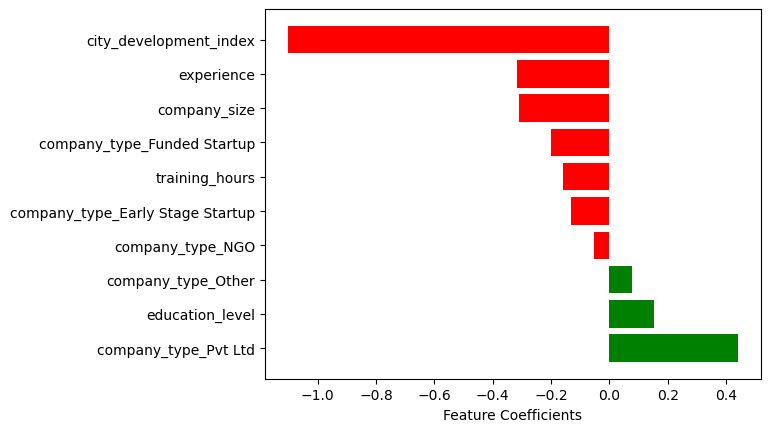

In [136]:
visualize_coefs(coef_dict)

The bar chart shows which features push the surrogate model's prediction up or down.

*   Negative coefficients, such as `city_development_index` and `experience`, push the prediction toward not looking for a job change.
*   Positive coefficients, such as `education_level` and `company_type_Pvt Ltd`, push the prediction toward looking for a job change.

These coefficients directly explain the surrogate model. They only indirectly explain the black-box model, because the surrogate model is only a copy of the black-box model. The better the fidelity, the more useful this explanation is.


#### **2. Decision tree surrogate model (exercise)**



In [ ]:
# Type your answer here
# Define a decision tree model
tree_surrogate = DecisionTreeClassifier(
    random_state=123, max_depth=5, max_features=10
)

In [138]:
# Type your answer here
# Train the decision tree model with X_test and y_blackbox, and make predictions on X_test
tree_surrogate.fit(X_test, y_blackbox)
y_surrogate = tree_surrogate.predict(X_test)

In [ ]:
# Measure how closely the surrogate model matches the black-box model
metrics.accuracy_score(y_blackbox, y_surrogate)

0.8213820078226858

After training the Decision Tree surrogate model, you can export and print the tree rules. These rules explain the decision tree surrogate directly. If the decision tree has good fidelity, the rules can also give an approximate explanation of the black-box model.


In [140]:
tree_exp = export_text(tree_surrogate, feature_names=list(X_train.columns))

In [141]:
print(tree_exp)

|--- city_development_index <= 0.70
|   |--- experience <= 20.92
|   |   |--- training_hours <= 304.03
|   |   |   |--- company_type_Funded Startup <= 0.99
|   |   |   |   |--- city_development_index <= 0.69
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- city_development_index >  0.69
|   |   |   |   |   |--- class: 1.0
|   |   |   |--- company_type_Funded Startup >  0.99
|   |   |   |   |--- education_level <= 2.50
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- education_level >  2.50
|   |   |   |   |   |--- class: 0.0
|   |   |--- training_hours >  304.03
|   |   |   |--- class: 0.0
|   |--- experience >  20.92
|   |   |--- city_development_index <= 0.67
|   |   |   |--- education_level <= 2.07
|   |   |   |   |--- training_hours <= 44.50
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- training_hours >  44.50
|   |   |   |   |   |--- class: 0.0
|   |   |   |--- education_level >  2.07
|   |   |   |   |--- company_size <= 6.50
|   |   |   |   |   |--- cla

### **Local Interpretable Model-Agnostic Explanations (LIME)**


Permutation feature importance, PDP, and global surrogate models help us understand the black-box model's overall behavior. Sometimes, however, we want to explain just one prediction.

**LIME** explains one prediction at a time. Here, one prediction means the model's output for one sample, such as one employee. 

For example, LIME can explain why the black-box model predicts that one employee is unlikely to look for a new job.

LIME is a **local explanation method**. It explains one selected example, not the whole model.


The main idea is to build a simple model near the selected example. This simple model is easier to understand, and it is used to explain the black-box model's prediction for that example.

The general process is shown in the flowchart below:


![Local interpretable model-agnostic method](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/module6_model_interpretability/images/lime.png)


We can use the open-source [lime](https://github.com/marcotcr/lime) package to build the LIME explainer.


First, we define a `LimeTabularExplainer`. This type of explainer is used for tabular datasets, such as the employee job-change dataset in this lab.


Here is what LIME does after we choose one example to explain:

- It creates many altered copies of the selected example.
- Each altered copy is made by changing some feature values.
- It sends those altered copies to the black-box model.
- It records how the black-box model's prediction changes.
- It gives more weight to altered copies that are more similar to the original example.
- It trains a simple local model using these altered copies and their black-box predictions.

The final explanation comes from this simple local model. If changing a feature moves the prediction a lot near the selected example, LIME treats that feature as important for that one prediction.


In [ ]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    # Set the training dataset to be X_test.values (2-D Numpy array)
    training_data=X_test.values,
    # Set the mode to be classification
    mode="classification",
    # Set class names to be `Not Changing` and `Changing`
    class_names=["Not Changing", "Changing"],
    # Set feature names
    feature_names=list(X_train.columns),
    # Avoid LIME's default Ridge-based feature selection, which is not compatible with this SciPy version
    feature_selection="none",
    random_state=123,
    verbose=True,
)

Now, let's select one employee from `X_test`. We will use LIME to explain the black-box model's prediction for this employee.


In [143]:
instance_index = 19
selected_instance = X_test.iloc[[instance_index]]
lime_test_instance = selected_instance.values.reshape(-1)
selected_instance

,city_development_index,training_hours,company_size,experience,education_level,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd
8659,0.924,74.0,7.0,16.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0


Let's make a quick summary of this employee:
- This employee's city is well developed, with a city development index greater than 0.9.
- This employee has completed 74 training hours.
- This employee works at a very large company. In this dataset, `7` means more than 10,000 employees.
- This employee has more than 16 years of experience.
- This employee works at a private limited company.
- This employee has a Master's degree or higher.

The black-box model predicts that this employee's probability of looking for a job change is `0.03`. This means the model thinks this employee is very unlikely to look for a new job.


Next, we ask `LimeTabularExplainer` to explain this prediction. LIME will create altered copies of this employee, get predictions from the black-box model, and fit a simple local model around this employee.


Intercept 0.9276965145639837
Prediction_local [0.4866052]
Right: 0.030869565217391304


/home/wusu/anaconda3/envs/Python_3_10/lib/python3.10/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


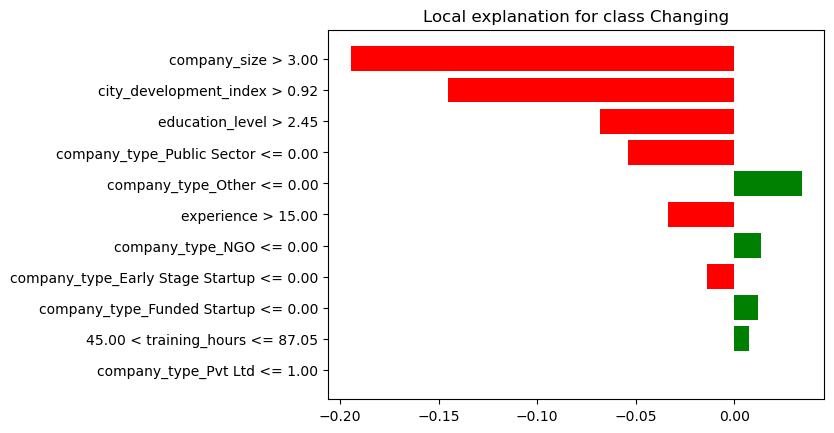

In [ ]:
exp = explainer.explain_instance(
    # Instance to explain
    lime_test_instance,
    # The prediction from black-box model
    black_box_model.predict_proba,
    # Use max 10 features
    num_features=10,
    # Avoid LIME's default Ridge model, which is not compatible with this SciPy version
    model_regressor=LinearRegression(),
)
exp.as_pyplot_figure()

`LimeTabularExplainer` outputs a bar chart. The chart shows which features had the strongest influence on this employee's prediction.

For this employee, the main reasons include:
- The employee works at a very large company.
- The employee lives in a well-developed city.
- The employee has a Master's degree or higher.
- The employee has more than 15 years of experience.
- The employee's company is not an NGO or startup.

These factors help explain why the black-box model predicts a low probability of job change for this employee. This is a local explanation: it explains this employee's prediction, not the whole model.


#### **Exercise** 
Find other employees in the dataset and use `LimeTabularExplainer` to explain the black-box model's prediction for each selected employee.


Selected employee index: 6737
Predicted probability of looking for a job change: 0.5


,city_development_index,training_hours,company_size,experience,education_level,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd
6737,0.918003,81.0,2.0,10.285324,0.714676,0.0,0.285324,0.0,0.0,0.0,0.714676


Intercept 0.7188709557255217
Prediction_local [0.845264]
Right: 0.5


/home/wusu/anaconda3/envs/Python_3_10/lib/python3.10/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


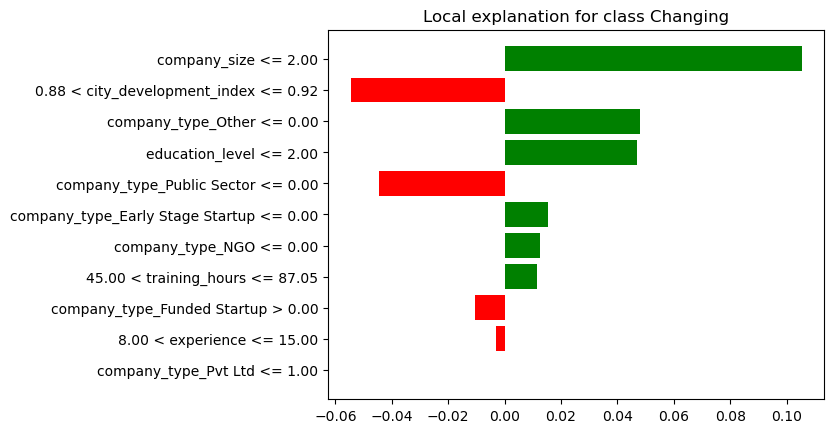

In [ ]:
# Exercise: choose another employee and explain the prediction with LIME

# Step 1: Get the black-box model's predicted probability for each employee in X_test.
# We use [:, 1] because class 1 means "Changing" or looking for a job change.
pred_probs = black_box_model.predict_proba(X_test)[:, 1]

# Step 2: Create a table to help choose interesting employees to explain.
lime_candidates = X_test.copy()
lime_candidates["predicted_probability"] = pred_probs

# Step 3: Pick useful examples.
# Low probability: model thinks this employee is unlikely to look for a job change.
low_probability_index = lime_candidates["predicted_probability"].idxmin()

# High probability: model thinks this employee is likely to look for a job change.
high_probability_index = lime_candidates["predicted_probability"].idxmax()

# Middle probability: model is less certain, close to 0.50.
middle_probability_index = (
    (lime_candidates["predicted_probability"] - 0.5).abs().idxmin()
)

# Step 4: Choose which employee to explain.
# Try changing this value to low_probability_index, high_probability_index,
# or middle_probability_index.
selected_index = middle_probability_index

# Step 5: Prepare the selected employee for LIME.
selected_instance = X_test.loc[[selected_index]]
lime_test_instance = selected_instance.values.reshape(-1)

print("Selected employee index:", selected_index)
print(
    "Predicted probability of looking for a job change:",
    lime_candidates.loc[selected_index, "predicted_probability"],
)
display(selected_instance)

# Step 6: Explain this employee's prediction with LIME.
exp = explainer.explain_instance(
    lime_test_instance,
    black_box_model.predict_proba,
    num_features=10,
    model_regressor=LinearRegression(),
)

exp.as_pyplot_figure()

## **Next Steps**


We have learned and applied several model-agnostic explanation methods in this lab, including permutation feature importance, PDP, global surrogate models, and LIME. There are many other methods, such as feature interactions, Individual Conditional Expectation, and SHAP values, but we do not have enough time to explain them all in this course. 

Here are references for other popular model explanation methods:
- [Predictive learning via rule ensembles](https://arxiv.org/abs/0811.1679)
- [A Unified Approach to Interpreting Model Predictions](https://arxiv.org/abs/1705.07874)
- [Peeking Inside the Black Box: Visualizing Statistical Learning with Plots of Individual Conditional Expectation](https://arxiv.org/abs/1309.6392)


## **Authors**


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/), Su Wu


Copyright © 2021 IBM Corporation. All rights reserved.
